# Quantum vs Classical Measurement, a Qiskit Investigation 
##### Bryan Milosevic-Hill 2026
---

 #### I have always heard in pop culture and in mainstream depictions of quantum computers that measurement is destructive and changes the state of the system. As somebody with a rigorous background in computer science I was initially left wondering "How do you build a useful computer that can't read freely from memory". 
 I've since read quite a bit on the subject, but this notebook is my first time actually interfacing with a quantum computer. It is a departure from the kind of computation I am trained in, and a step toward understanding quantum computing as something I can actually experiment with rather than just read about.

 You do not get strong by watching somebody else pick up the weights, and no amount of Nielsen and Chuang can replace the experience of experimenting with real quantum hardware. I did not learn to code by reading, I did so by the iterative process of learning smaller skills and building up to solve harder and harder questions. This notebook is that, the first time I experiment and learn quantum information practically.

<br>

> *This is the first notebook I have written alongside my independent study and pursuit of the [IBM Qiskit Developer Certification](https://www.ibm.com/training/certification/ibm-certified-quantum-computation-using-qiskit-v2x-developer-associate-C9008400).*
<br>

---
## <u>**Table of Contents**</u>
#### 1. [Classical Measurements](#Building-intuition-around-Classical-Measurements)
#### 2. [Quantum Measurement and Variance](#Quantum-Measurement-and-Variance)
#### 3. [Changing Theta to Match the Weighted Coin](#Changing-theta-to-match-the-behaviour-of-the-weighted-coin)
#### 4. [Confirming Measurements on IBM Fez](#Confirming-Measurements-on-IBM-Fez)
#### 5. [Varying Theta With Time](#Varying-Theta-With-Time)
#### 6. [IBM Fez: Varying Theta](#IBM-Fez-Varying-Theta)
#### 7. [IBM Fez: Data Representation and Comparison](#IBM-Fez-Varying-Theta-Initial-Data-Representation-and-Comparison)
#### 8. [Signal Processing](#Signal-Processing)
#### 9. [Chasing Unexpected Peaks](#Chasing-Unexpected-Peaks)
#### 10. [Conclusion](#Conclusion)
#### 11. [References](#References)
---

#### Ultimately I set out to answer the following question for myself:

`What does it mean to make discrete measurements on a Quantum System and how does that vary from Classical measurements?`

---

## Classical Measurements

In classical settings, measurements are discrete even when the probability distribution is constant. Take a coin for instance, a familiar system to model probabilities. After a singular flip, recording the state offers little to no information regarding the behaviour of the system long term, or as you increase the instances of flipping.

In the cell below, I model an unfair (biased) coin that has a higher chance of one state being measured over another.

$$ p = 0.3 $$

Each event simulates flipping this virtual coin with a 30 percent chance to land heads and 70 percent chance to land tails. This is modelled using a Bernoulli random variable \(x \in \{0,1\}\). As we finish running a single round of 50 measurements, we calculate the mean of the sample.

Building evidence to model behaviour off of, it is important to sample many trial means and take the mean of those, as a singular train of N coin flips can really only tell you so much. Outliers can lead one to jump to incorrect conclusions, and ultimately a singular mean does not reveal much about the underlying distribution of the system. It is important to measure in such a way to more accurately characterize the fluctuations of a system.

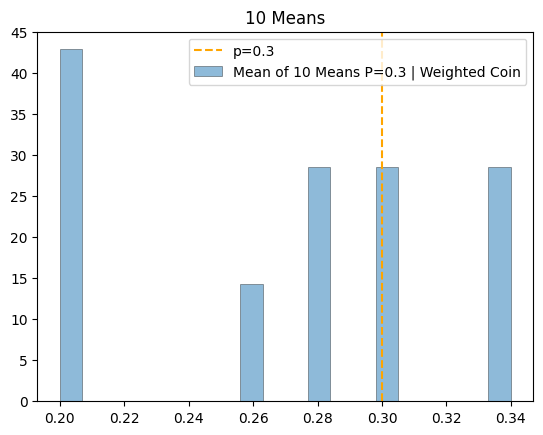

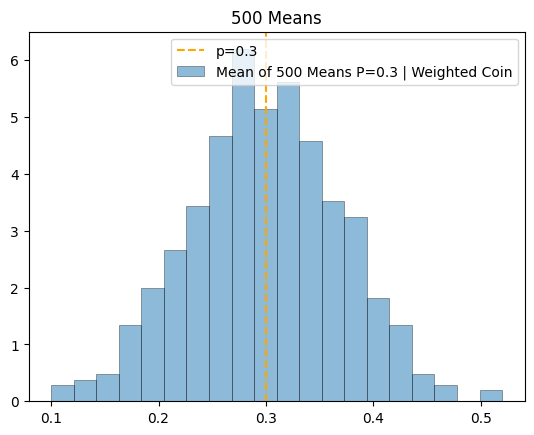

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#we define a weighted coin to simulate classic events and measuermenst of these classical events
p=0.3
outcomes=[1,0]
prob=[p,1-p]
classicMeans = []
for i in range (500):
    classicSample = np.random.choice(outcomes,size =50,p=prob)
    if (i == 10):
        plt.title("10 Means")
        plt.axvline(0.3, color='orange', linestyle='--',label="p=0.3")
        plt.hist(classicMeans, bins=20, density=True, alpha=0.5,edgecolor = 'black',linewidth = 0.5, label="Mean of 10 Means P=0.3 | Weighted Coin");
        plt.legend()
        plt.show()
    classicMeans.append(np.mean(classicSample))

plt.axvline(0.3, color='orange', linestyle='--',label="p=0.3")
plt.title("500 Means")
plt.hist(classicMeans, bins=20,edgecolor = 'black',linewidth = 0.5, density=True, alpha=0.5, label="Mean of 500 Means P=0.3 | Weighted Coin");
plt.legend();

## Quantum Measurement and Variance

Now I wanted to repeat the above classical sampling and measurement within a quantum context. Instead of fixed probability values, the outcomes are determined by the state prior to measurement.

Below I initialize a singular qubit $|0\rangle$. A rotation on the $Y$ axis is applied with angle $\theta = \frac{\pi}{2}$. This rotation is applied via the use of an [$R_y(\theta)$ gate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RYGate)

$$
R_Y(\theta)
=
\exp\!\left(-i \frac{\theta}{2} Y\right)
=
\begin{pmatrix}
\cos\!\left(\frac{\theta}{2}\right) & -\sin\!\left(\frac{\theta}{2}\right) \\
\sin\!\left(\frac{\theta}{2}\right) & \cos\!\left(\frac{\theta}{2}\right)
\end{pmatrix}
$$

The qubit is then measured again and we record its state. This is the quantum system I propose to be analogous to our classical coin system above. The expected $P=0.5$ via its default behaviour is what allows me to draw this parallel between an $R_y$ gate and a fair coin. We will also see that both theoretically and in practice, we can use this to match our weighted coin example above.

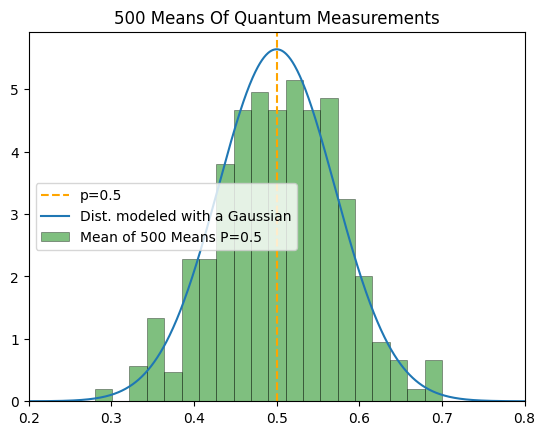

In [117]:
from qiskit import QuantumCircuit as qc
from qiskit import transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

from IPython.display import display

sim = AerSimulator()

theta = np.pi/2 # theta = pi/2
quantumMeans = []

def curve(samples,p,num):
  mu = p
  sigma = np.sqrt(p*(1-p)/num)
  x = np.linspace(min(samples) - 0.1, max(samples)+0.1, 1000)
  y = (1 / np.sqrt(2*np.pi*sigma**2)) *  np.exp(-0.5 * (x - mu)**2 /sigma**2)
  return x,y

for i in range (500):
    circA = qc(1,1)
    circA.ry(theta,0) # explain this on paper
    circA.measure(0,0)
    comp = transpile(circA,sim)
    result = sim.run(comp, shots = 50)
    counts = result.result().get_counts()

    mean = counts.get('1',0)/50
    quantumMeans.append(mean)
plt.xlim(0.2, 0.8)
plt.axvline(0.5, color='orange', linestyle='--',label="p=0.5")
plt.title("500 Means Of Quantum Measurements")
x1, y1 = curve(quantumMeans,.5,50)
plt.plot(x1, y1, label="Dist. modeled with a Gaussian")
plt.hist(quantumMeans, bins=20,edgecolor = 'black',linewidth = 0.5, density=True,color = 'green', alpha=0.5, label="Mean of 500 Means P=0.5");
xmin, xmax = plt.xlim()
plt.legend();
plt.show();


## Changing theta to match the behaviour of the weighted coin

To match the weighted coin with $P = 0.3$, we need $\sin^2\left(\frac{\theta}{2}\right) = 0.3$. Applying $R_Y(\theta)$ to $|0\rangle$:

$$R_Y(\theta)|0\rangle = \cos\left(\frac{\theta}{2}\right)|0\rangle + \sin\left(\frac{\theta}{2}\right)|1\rangle$$

$$P(|1\rangle) = \sin^2\left(\frac{\theta}{2}\right) = \sin^2\left(\arcsin\left(\sqrt{0.3}\right)\right) = 0.3$$
Thus for $p = 0.3$

$$\theta = 2\arcsin\left(\sqrt{0.3}\right)$$

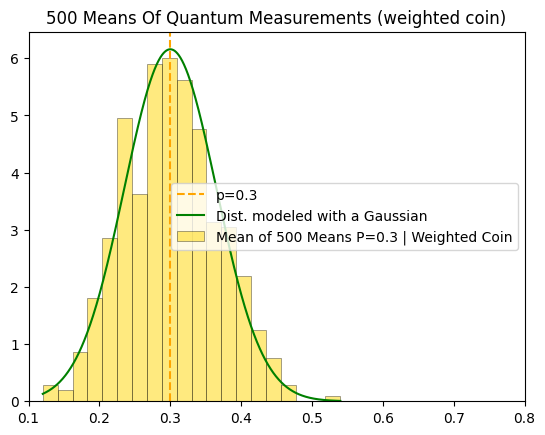

In [ ]:
from qiskit import QuantumCircuit as qc
from qiskit import transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

from IPython.display import display

sim = AerSimulator()
p = 0.3
theta = 2 * np.arcsin(np.sqrt(p))
quantumMeans = []

for i in range (500):
    circA = qc(1,1)
    circA.ry(theta,0) # explain this on paper
    circA.measure(0,0)
    comp = transpile(circA,sim)
    result = sim.run(comp, shots = 50)
    counts = result.result().get_counts()

    mean = counts.get('1',0)/50
    quantumMeans.append(mean)
plt.xlim(0.1, .8)
plt.axvline(0.3, color='orange', linestyle='--',label="p=0.3")
plt.title("500 Means Of Quantum Measurements (weighted coin)")
x1, y1 = curve(quantumMeans,.3,50)
plt.plot(x1, y1, label="Dist. modeled with a Gaussian", color = 'green')
plt.hist(quantumMeans, bins=20,edgecolor = 'black',linewidth = 0.5, density=True,color = 'gold',  alpha=0.5, label="Mean of 500 Means P=0.3 | Weighted Coin");
plt.legend();


---
Variances arise from the fact that when the probability of measuring $|1\rangle$ is fixed, each individual shot still behaves probabilistically, so repeated measurements naturally fluctuate around the expected value. This fluctuation is more than just the fluctuating means of coin flips, as the probability is not coming from a classical coin or ordinary luck of the draw. In the quantum regime, these probabilities come from the squared amplitudes of its superposition state through the Born rule, which is the measurement framework I was presented when reading Nielsen and Chuang.

# Confirming Measurements on IBM Fez

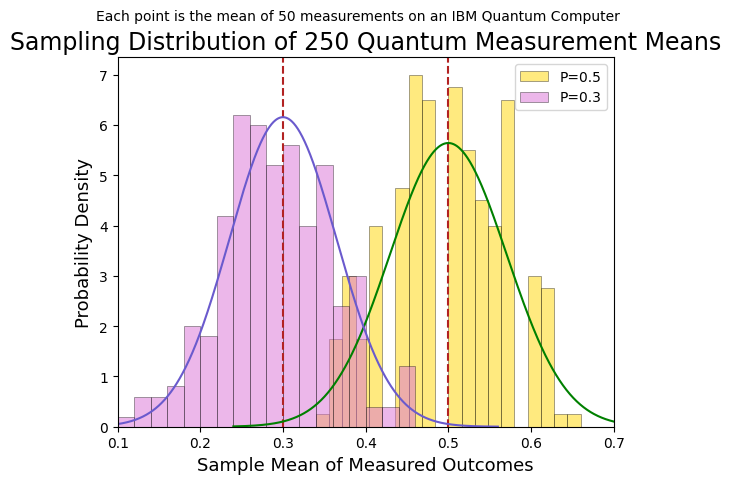

In [ ]:
from qiskit import QuantumCircuit as qc
from qiskit import transpile
import numpy as np
import matplotlib.pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2


from IPython.display import display

p = 0.3
theta1 = 2 * np.arcsin(np.sqrt(p))
theta2 = np.pi/2

meanCount = 250
shotsPer = 50
totalSamples = meanCount * shotsPer

circA = qc(1, 1)
circB = qc(1, 1)
circA.ry(theta1, 0)
circB.ry(theta2, 0)
circA.measure(0, 0)
circB.measure(0, 0)

# interface with IBM
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)

compA = transpile(circA, backend=backend, optimization_level=1)
compB = transpile(circB, backend=backend, optimization_level=1)

sampler = SamplerV2(mode=backend)
job = sampler.run([compA, compB], shots=totalSamples)
result = job.result()

countsA = result[0].data.c.get_counts()
countsB = result[1].data.c.get_counts()

def curve(samples,p,num):
  mu = p
  sigma = np.sqrt(p*(1-p)/num)
  x = np.linspace(min(samples) - 0.1, max(samples)+0.1, 1000)
  y = (1 / np.sqrt(2*np.pi*sigma**2)) *  np.exp(-0.5 * (x - mu)**2 /sigma**2)
  return x,y

def countsToBitlist(counts, total):
    bits = []
    for bitstr, c in counts.items():
        bits.extend([int(bitstr)] * c)
    bits = np.array(bits)
    if len(bits) != total:
        raise ValueError("Expected %d shots, got %d" % (total, len(bits)))
    np.random.shuffle(bits)
    return bits

def bitlistToMean(bits, shostPer):
    return [np.mean(bits[i:i+shostPer])
            for i in range(0, len(bits), shostPer)]

bitsA = countsToBitlist(countsA, totalSamples)
bitsB = countsToBitlist(countsB, totalSamples)

quantumMeansW = bitlistToMean(bitsA, shotsPer)  # corresponds to p=0.3
quantumMeansF = bitlistToMean(bitsB, shotsPer)  # corresponds to p=0.5


plt.xlim(0.1, .7)
plt.axvline(0.3, color='firebrick', linestyle='--')
plt.axvline(0.5, color='firebrick', linestyle='--')
plt.title("Sampling Distribution of 250 Quantum Measurement Means", fontsize=17)
plt.suptitle("Each point is the mean of 50 measurements on an IBM Quantum Computer", fontsize=10)
plt.xlabel("Sample Mean of Measured Outcomes", fontsize=13)
plt.ylabel("Probability Density", fontsize=13)
x1, y1 = curve(quantumMeansF,.5,50)
x2, y2 = curve(quantumMeansW,.3,50)
plt.plot(x1, y1,  color = 'green')
plt.plot(x2, y2, color = 'slateblue')
plt.hist(quantumMeansF, bins=20,edgecolor = 'black',linewidth = 0.5, density=True,color = 'gold',  alpha=0.5, label="P=0.5");
plt.hist(quantumMeansW, bins=20,edgecolor = 'black',linewidth = 0.5, density=True,color = 'orchid',  alpha=0.5, label="P=0.3");
plt.legend();
plt.show();


### Varying Theta With Time

Now that I have explored the behaviour of a quantum system’s parameters after measurement, and observed those readings collapse into discrete classical readings that matched the classical system of a weighted coin, I was struck with a new curiosity.

I wanted to see what variance would arise if I decided to vary $\theta$ with time. I was stuck between two options: varying $\theta$ along a linear relation, or a cyclical one. I ended up settling on

$$
\theta(t) = \theta_c + A\sin(2\pi f t)
$$

where $\theta_c$ is the centre angle, $A$ is the amplitude, and $f$ is the driving frequency. I chose a sinusoid to see how consistent the readings would be and whether they would diverge as $t$ grows large. Should anything arise, I thought it would be obvious given how predictable trigonometric functions are with their periodic nature.

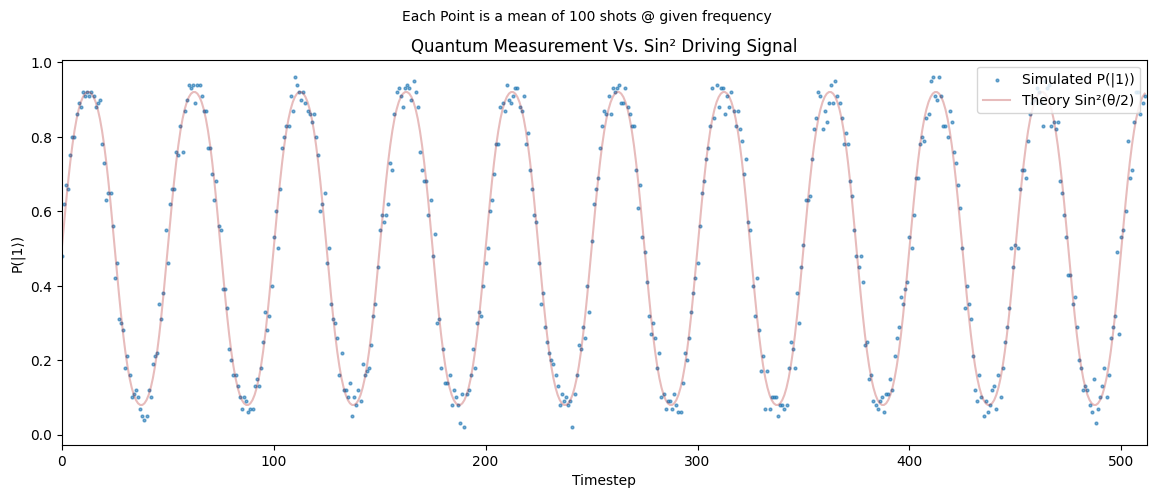

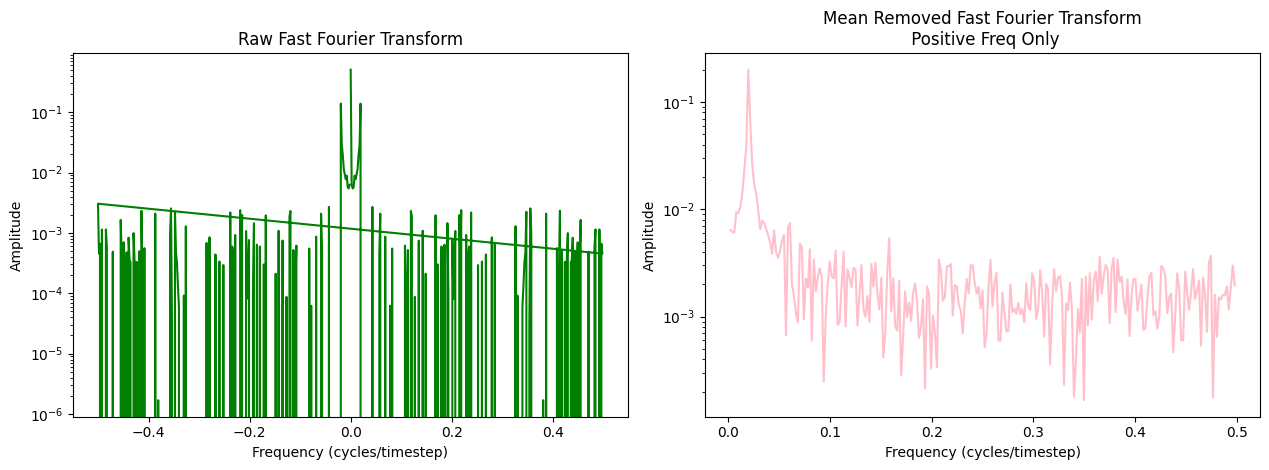

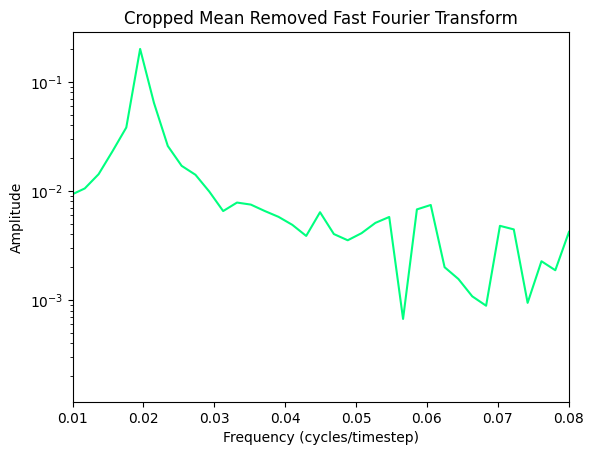

In [94]:
from qiskit import QuantumCircuit as qc
from qiskit import transpile
from qiskit.quantum_info import Statevector
from scipy.fft import fft, ifft, fftfreq
from qiskit.visualization import plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator


from IPython.display import display

sim = AerSimulator()

theta = np.pi/2 # theta = pi/2
quantumMeans = []
centre = np.pi / 2
freq = 0.02
amp = 1 
N = 512 # power of 2 for predicatble computation
shots = 100
t = np.arange(N)
thetas = centre + amp * np.sin(2 * np.pi * freq * t)


for a in range (0,len(thetas)):
    circA = qc(1,1)
    circA.ry(thetas[a],0) 
    circA.measure(0,0)
    comp = transpile(circA,sim)
    result = sim.run(comp, shots = shots)
    counts = result.result().get_counts()

    mean = counts.get('1',0)/shots
    quantumMeans.append(mean)


plt.figure(figsize=(14, 5))
plt.title("Quantum Measurement Vs. Sin² Driving Signal")
plt.suptitle("Each Point is a mean of 100 shots @ given frequency", fontsize=10)
plt.scatter(t[:512], quantumMeans[:512], s=4, alpha=0.6, label="Simulated P(|1⟩)")
plt.plot(t[:512], (np.sin(thetas/2)**2)[:512], color="firebrick", alpha=0.3, label="Theory Sin²(θ/2)")
plt.xlim(0,512)
plt.xlabel("Timestep")
plt.ylabel("P(|1⟩)")
plt.legend(loc="upper right");
plt.show();

ck = fft(quantumMeans) / N
nuk = fftfreq(N, 1)



centQm = np.array(quantumMeans) - np.mean(quantumMeans)
ckAd = fft(centQm) / N
mask = nuk > 0 


fig, (ax1, ax2) = plt.subplots(1, 2,figsize = (12.8, 4.8))

ax1.plot(nuk, np.real(ck), color = "green")
ax1.set_yscale("log")
ax1.set_title("Raw Fast Fourier Transform")
ax1.set_xlabel("Frequency (cycles/timestep)")
ax1.set_ylabel("Amplitude")

ax2.set_yscale("log")
ax2.plot(nuk[mask], np.abs(ckAd[mask]), color = "pink")
ax2.set_title("Mean Removed Fast Fourier Transform\n Positive Freq Only")
ax2.set_xlabel("Frequency (cycles/timestep)")
ax2.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

plt.xlim(0.01,0.08)

plt.yscale("log")
plt.title("Cropped Mean Removed Fast Fourier Transform")
plt.xlabel("Frequency (cycles/timestep)")
plt.ylabel("Amplitude")
plt.plot(nuk[mask], np.abs(ckAd[mask]), color = "springgreen");

# IBM Fez Varying Theta

In [64]:
from qiskit import QuantumCircuit as qc
from qiskit import transpile
import numpy as np
import matplotlib.pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

service = QiskitRuntimeService()
backend = service.backend("ibm_fez")

centre = np.pi / 2
freq = 0.02
amp = 1
N = 512
shots = 100
t = np.arange(N)
thetas = centre + amp * np.sin(2 * np.pi * freq * t)

circuits = []
for theta in thetas:
    circ = qc(1, 1)
    circ.ry(theta, 0)
    circ.measure(0, 0)
    circuits.append(circ)

compiled = transpile(circuits, backend=backend, optimization_level=1)

sampler = SamplerV2(mode=backend)
job = sampler.run(compiled, shots=shots)
result = job.result()

quantumMeansFez = []
for i in range(N):
    counts = result[i].data.c.get_counts()
    quantumMeansFez.append(counts.get('1', 0) / shots)

np.save("quantumMeansFez.npy", np.array(quantumMeansFez))
np.save("thetasFez.npy", thetas) #this time im saving my readings oops


# IBM Fez Varying Theta Initial Data Representation and Comparison 

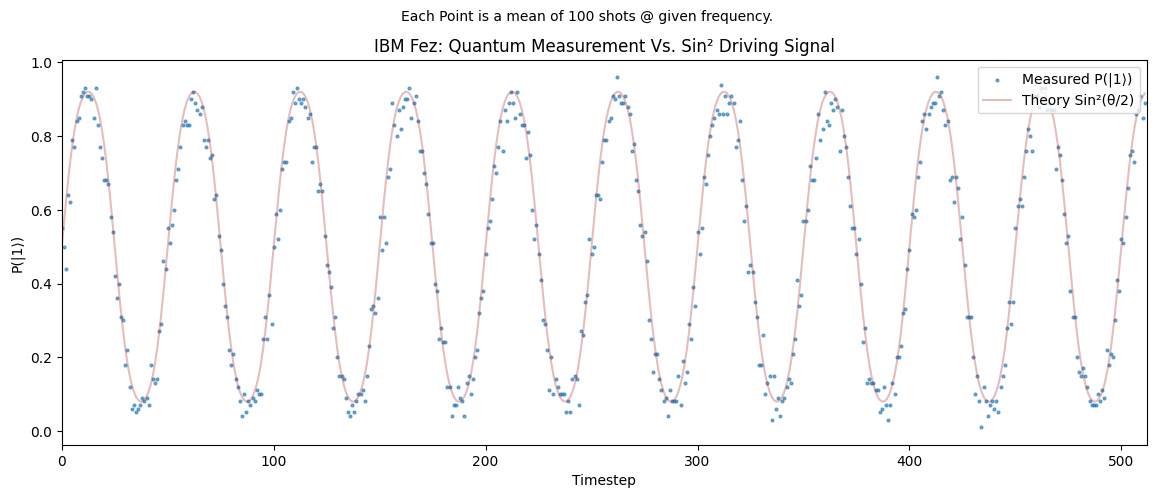

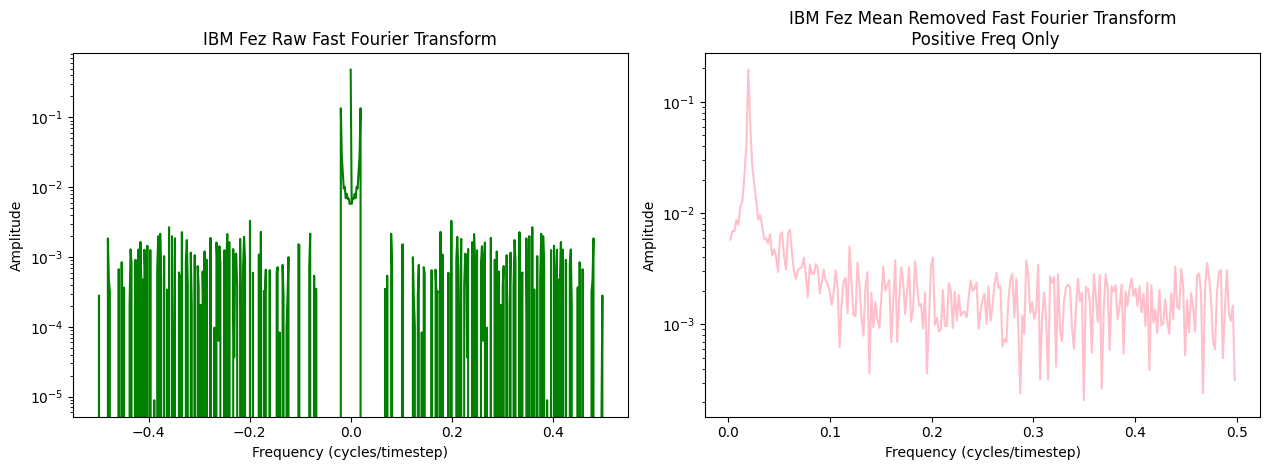

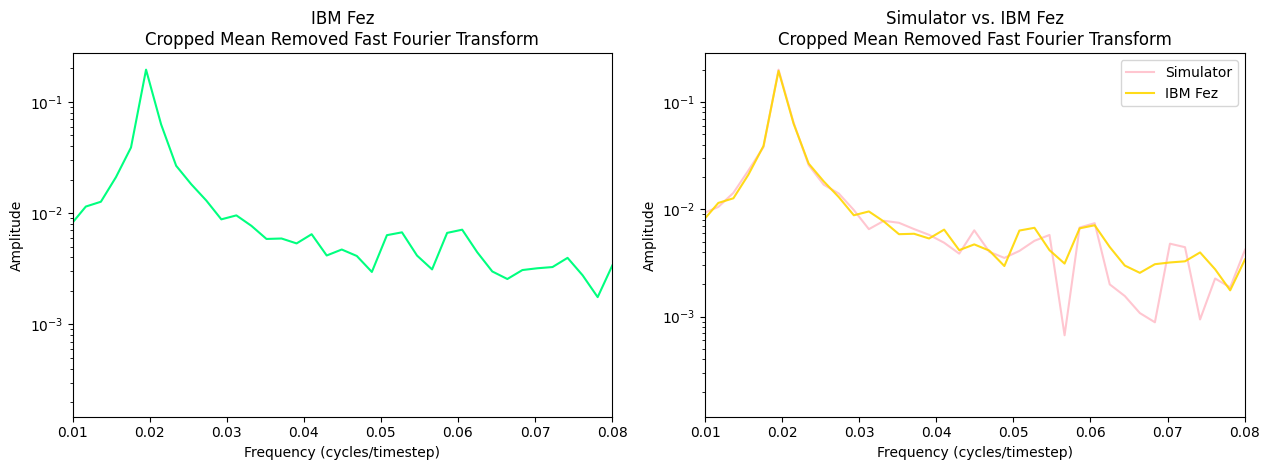

In [95]:
from scipy.fft import fft, fftfreq

quantumMeansFez = np.load("quantumMeansFez.npy")
thetas = np.load("thetasFez.npy")
N = len(quantumMeansFez)
t = np.arange(N)

plt.figure(figsize=(14, 5))
plt.title("IBM Fez: Quantum Measurement Vs. Sin² Driving Signal")
plt.suptitle("Each Point is a mean of 100 shots @ given frequency.", fontsize=10)
plt.scatter(t[:512], quantumMeansFez[:512], s=4, alpha=0.6, label="Measured P(|1⟩)")
plt.plot(t[:512], (np.sin(thetas/2)**2)[:512], color="firebrick", alpha=0.3, label="Theory Sin²(θ/2)")
plt.xlim(0,512)
plt.xlabel("Timestep")
plt.ylabel("P(|1⟩)")

plt.legend();
plt.legend(loc="upper right");
plt.show();

ckFez = fft(quantumMeansFez) / N
nukFez = fftfreq(N, 1)

centQmFez = np.array(quantumMeansFez) - np.mean(quantumMeansFez)
ckAdFez = fft(centQmFez) / N
mask = nukFez > 0

fig, (ax1, ax2) = plt.subplots(1, 2,figsize = (12.8, 4.8))

ax1.plot(nukFez, np.real(ckFez), color = "green")
ax1.set_yscale("log")
ax1.set_title("IBM Fez Raw Fast Fourier Transform")
ax1.set_xlabel("Frequency (cycles/timestep)")
ax1.set_ylabel("Amplitude")

ax2.set_yscale("log")
ax2.plot(nukFez[mask], np.abs(ckAdFez[mask]), color = "pink")
ax2.set_title("IBM Fez Mean Removed Fast Fourier Transform\n Positive Freq Only")
ax2.set_xlabel("Frequency (cycles/timestep)")
ax2.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.8))

ax1.set_xlim(0.01, 0.08)
ax1.set_yscale("log")
ax1.set_title("IBM Fez\nCropped Mean Removed Fast Fourier Transform")
ax1.plot(nukFez[mask], np.abs(ckAdFez[mask]), color="springgreen")
ax1.set_xlabel("Frequency (cycles/timestep)")
ax1.set_ylabel("Amplitude")

ax2.set_xlim(0.01, 0.08)
ax2.set_yscale("log")
ax2.set_title("Simulator vs. IBM Fez\nCropped Mean Removed Fast Fourier Transform")
ax2.plot(nuk[mask], np.abs(ckAd[mask]), color="pink", label="Simulator", alpha = 0.9)
ax2.plot(nukFez[mask], np.abs(ckAdFez[mask]), color="gold", label="IBM Fez", alpha = 0.9)
ax2.set_xlabel("Frequency (cycles/timestep)")
ax2.set_ylabel("Amplitude")
ax2.legend()

plt.tight_layout()
plt.show()

---
# Signal Processing


In my **Computational Methods for Physicists and Engineers** class, I was introduced to the technique of applying windows to de-noise and make sense of signals. I decided to apply a Hann window and add it to the “signal chain,” as the finite length of my readings could create [spectral leakage](https://en.wikipedia.org/wiki/Spectral_leakage). Reducing this leakage allows us to get a clearer picture of what is going on.

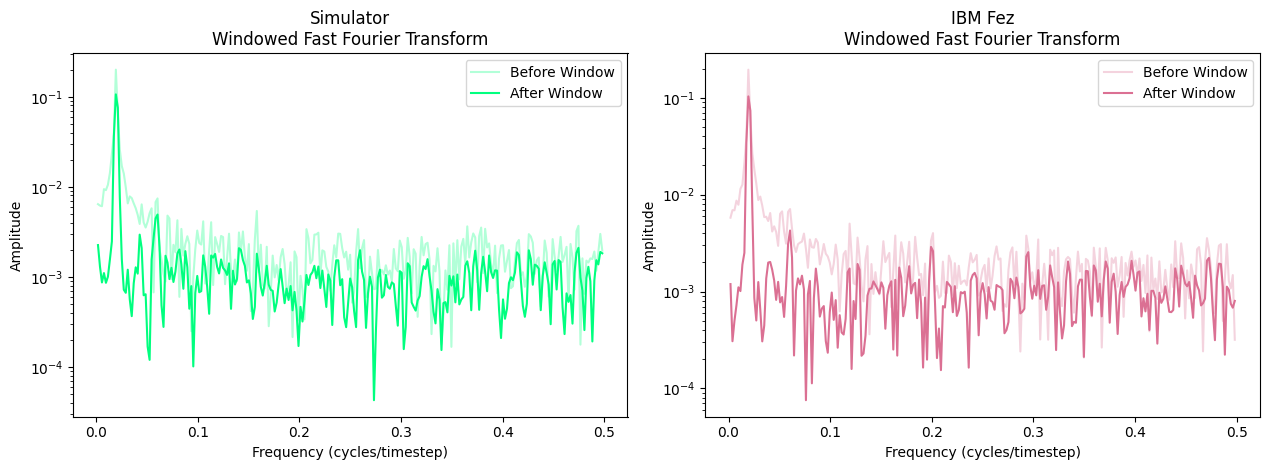

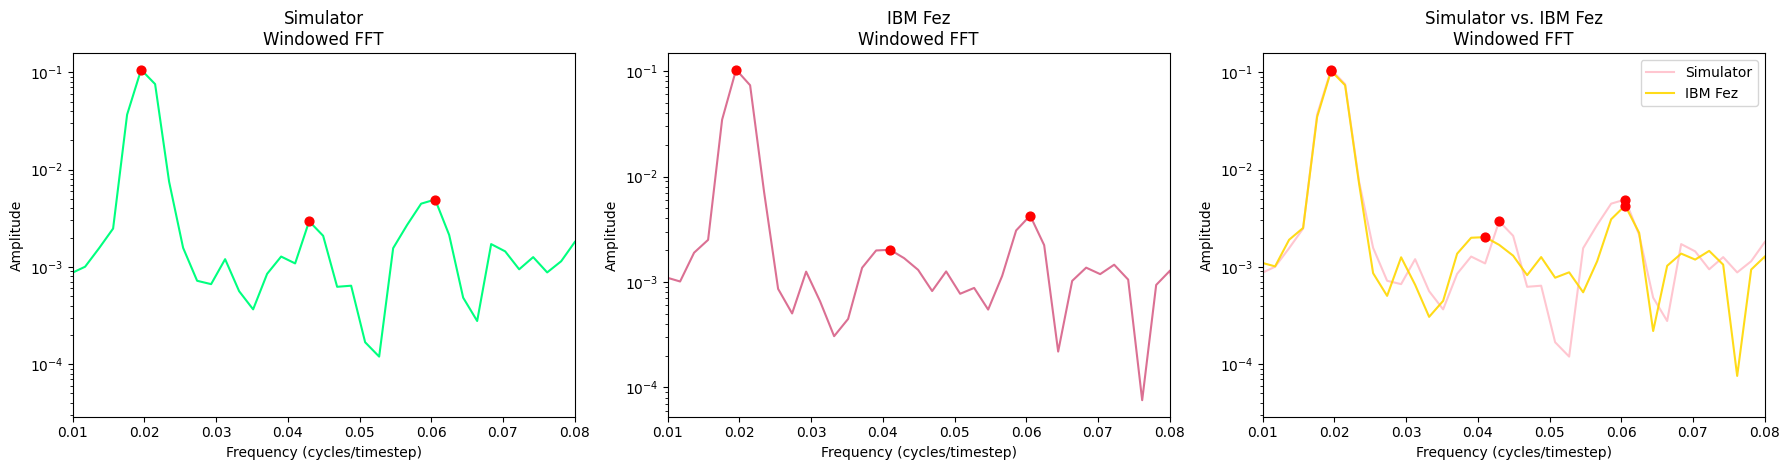

Simulator Peaks: 
f = 0.0195 | amp = 0.1062
f = 0.0430 | amp = 0.0029
f = 0.0605 | amp = 0.0049

IBM Fez Peaks:
f = 0.0195 | amp = 0.1032
f = 0.0410 | amp = 0.0020
f = 0.0605 | amp = 0.0043


In [122]:
from scipy.signal import find_peaks
window = np.hanning(N)

# sim
windowedSim = centQm * window
ckWindowed = fft(windowedSim) / N

# IBM Fez
centQmFez = np.array(quantumMeansFez) - np.mean(quantumMeansFez)
windowedFez = centQmFez * window
ckWindowedFez = fft(windowedFez) / N


#peaks
limit = (nuk > 0.01) & (nuk < 0.08)

peaksSim, _ = find_peaks(np.abs(ckWindowed[limit]), height=2e-3, prominence=1e-3)
peaksFez, _ = find_peaks(np.abs(ckWindowedFez[limit]), height=2e-3, prominence=1e-3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.8))

ax1.set_yscale("log")
ax1.set_title("Simulator\nWindowed Fast Fourier Transform")
ax1.plot(nuk[mask], np.abs(ckAd[mask]), color="springgreen", alpha=0.3, label="Before Window")
ax1.plot(nuk[mask], np.abs(ckWindowed[mask]), color="springgreen", label="After Window")
ax1.set_xlabel("Frequency (cycles/timestep)")
ax1.set_ylabel("Amplitude")
ax1.legend()

ax2.set_yscale("log")
ax2.set_title("IBM Fez\nWindowed Fast Fourier Transform")
ax2.plot(nukFez[mask], np.abs(ckAdFez[mask]), color="palevioletred", alpha=0.3, label="Before Window")
ax2.plot(nukFez[mask], np.abs(ckWindowedFez[mask]), color="palevioletred", label="After Window")
ax2.set_xlabel("Frequency (cycles/timestep)")
ax2.set_ylabel("Amplitude")
ax2.legend()

plt.tight_layout()
plt.show()


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4.8))

ax1.set_xlim(0.01, 0.08)
ax1.set_yscale("log")
ax1.set_title("Simulator\nWindowed FFT")
ax1.scatter(nuk[limit][peaksSim], np.abs(ckWindowed[limit])[peaksSim], color="red", zorder=5, s=40, label="Peaks")
ax1.plot(nuk[mask], np.abs(ckWindowed[mask]), color="springgreen")
ax1.set_xlabel("Frequency (cycles/timestep)")
ax1.set_ylabel("Amplitude")

ax2.set_xlim(0.01, 0.08)
ax2.set_yscale("log")
ax2.set_title("IBM Fez\nWindowed FFT")
ax2.scatter(nukFez[limit][peaksFez], np.abs(ckWindowedFez[limit])[peaksFez], color="red", zorder=5, s=40, label="Peaks")
ax2.plot(nukFez[mask], np.abs(ckWindowedFez[mask]), color="palevioletred")
ax2.set_xlabel("Frequency (cycles/timestep)")
ax2.set_ylabel("Amplitude")

ax3.set_xlim(0.01, 0.08)
ax3.set_yscale("log")
ax3.set_title("Simulator vs. IBM Fez\nWindowed FFT")
ax3.scatter(nuk[limit][peaksSim], np.abs(ckWindowed[limit])[peaksSim], color="red", zorder=5, s=40)
ax3.scatter(nukFez[limit][peaksFez], np.abs(ckWindowedFez[limit])[peaksFez], color="red", zorder=5, s=40)
ax3.plot(nuk[mask], np.abs(ckWindowed[mask]), color="pink", label="Simulator", alpha=0.9)
ax3.plot(nukFez[mask], np.abs(ckWindowedFez[mask]), color="gold", label="IBM Fez", alpha=0.9)
ax3.set_xlabel("Frequency (cycles/timestep)")
ax3.set_ylabel("Amplitude")
ax3.legend()

plt.tight_layout()
plt.show()

print("Simulator Peaks: ")
for p in peaksSim:
    print("f = %.4f | amp = %.4f" % (nuk[limit][p], np.abs(ckWindowed[limit])[p]))

print("\nIBM Fez Peaks:")
for p in peaksFez:
    print("f = %.4f | amp = %.4f" % (nukFez[limit][p], np.abs(ckWindowedFez[limit])[p]))



## Chasing Unexpected Peaks
After processing the fast Fourier transforms, some unexpected peaks appeared, which were especially apparent after applying the Hann Window. Since I had hard coded the driving frequency to be `0.02`, that peak was easy enough to explain. What confused me was the appearance of additional peaks at `0.04` and `0.06`. I wanted to understand whether these were just noise, but the occurrence of them on both the simulator and my run on IBM Fez convinced me to look further. From here I wanted to see if there was some way I could analytically explain the emergence of these 'extra peaks'.


The angle I feed into the quantum computer does not simply come back out for me to read directly. Instead, after I pass that angle through an $R_y(\theta)$ gate and measure the qubit, what I get is the probability of measuring the state $|1\rangle$:

$$
P(|1\rangle) = \sin^2\left(\frac{\theta}{2}\right)
$$

Computed directly by seeing that the cosine contribution of the state vector corresponds to $|0\rangle$ after applying the $R_y(\theta)$ gate:

$$
R_y(\theta)|0\rangle
=
\cos\left(\frac{\theta}{2}\right)|0\rangle
+
\sin\left(\frac{\theta}{2}\right)|1\rangle
$$
So the probability of measuring $|1\rangle$ is the squared amplitude of the $|1\rangle$ component, as the $|0\rangle$ component is not within the scope of this specific measurement probability.

Using the identity

$$
\sin^2(x)=\frac{1-\cos(2x)}{2}
$$

we can write the probability of reading $|1\rangle$ as 

$$
P(|1\rangle)
=
\frac{1-\cos(\theta)}{2}
$$


So, after passing in a predictable and uniform sine wave for $\theta$, the measurements I receive do not behave in a one-to-one linear manner. The values are reshaped by the measurement probability, and new frequency components emerge seemingly as scalar multiples of the driven frequency, or at the very least with some regularity. To see this, we substitute the driving signal $\theta(t) = \theta_c + A\sin(2\pi f t)$ into the measurement probability:

$$
P(t) = \frac{1 - \cos\!\left(\theta_c + A\sin(2\pi f t)\right)}{2}
$$

Since $\cos$ of a sinusoid is not itself a sinusoid, this expression contains frequency content at $f$, $2f$, $3f$, and so on, exactly the peaks at `0.04` and `0.06` that appear in the FFT.

---


This partially explained why peaks showed up beyond the initial frequency, but I still wanted a more satisfying explanation. After some digging, I found that this same structure appears in [Quantum Sensing by Degen, Reinhard, and Cappellaro (Rev. Mod. Phys. 89, 035002, 2017)](https://arxiv.org/abs/1611.02427), where the [Ramsey](https://en.wikipedia.org/wiki/Ramsey_interferometry) transition probability is derived as



$$
p = \sin^2\left(\frac{\omega_0 t}{2}\right)
=
\frac{1}{2}\left[1-\cos(\omega_0 t)\right]
$$



which mimics the **exact** structure I was observing in my own results. It was interesting to see that these peaks were not just a bug, but a feature of quantum measurement itself, and of the probabilities that make it work. This helped instill in me the fact that qubit measurement probabilities are nonlinear by the nature of the system itself.






## **Conclusion**
### **What does it mean to make discrete measurements on a quantum system and how does that vary from classical measurements?**

Measurement means collapsing the superposition. It is the process of reading information that forces the quantum regime to manifest in a sensible classical way. This is correctly referred to as collapsing because so much of the qubit’s information is lost in the process of reading it. In the classical coin example, measurement is as trivial as physically observing the state and noting it down. Quantum measurement is not passive like that, as “noting down” the quantum state is a destructive process that leads to information loss.

Randomness arises from the very basis of a superposition; the qubit is more than one state at the same time before measurement. The perceived randomness comes from the measurement forcing the qubit to resolve into one definite outcome from the set of possible states it had before measurement. I began to learn how the probability amplitudes that underpin the behaviour of qubits work. The probabilities are determined by the squared amplitudes of the quantum state through the Born rule. So the randomness is not just measurement error or noise in the machine. It is built into the way quantum measurement converts a superposition into a classical reading.

--- 
